(200, 2) (200,)


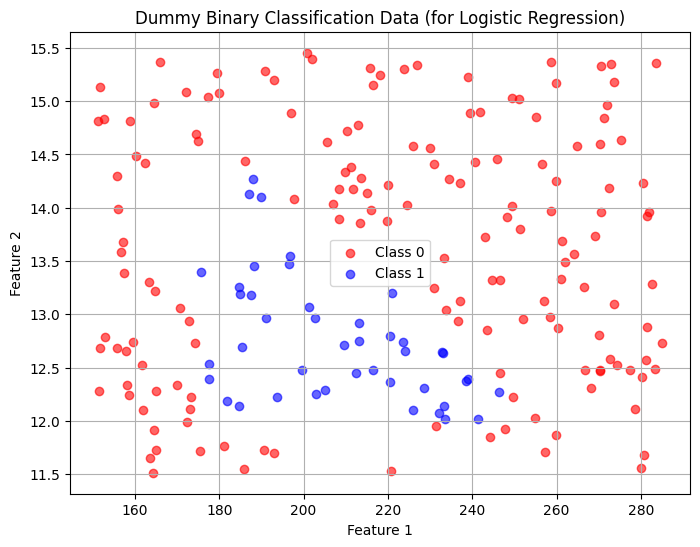

In [87]:
import numpy as np
from matplotlib import pyplot as plt

def load_coffee_data():
    """ Creates a coffee roasting data set.
        roasting duration: 12-15 minutes is best
        temperature range: 175-260C is best
    """
    rng = np.random.default_rng(2)
    X = rng.random(400).reshape(-1, 2)
    X[:, 1] = X[:, 1] * 4 + 11.5  # 12-15 min is best
    X[:, 0] = X[:, 0] * (285 - 150) + 150  # 350-500 F (175-260 C) is best
    Y = np.zeros(len(X))

    i = 0
    for t, d in X:
        y = -3 / (260 - 175) * t + 21
        if (t > 175 and t < 260 and d > 12 and d < 15 and d <= y):
            Y[i] = 1
        else:
            Y[i] = 0
        i += 1

    return (X, Y)


X, y = load_coffee_data()
print(X.shape, y.shape)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(X[y.flatten() == 0][:, 0], X[y.flatten() == 0][:, 1], color="red", label="Class 0", alpha=0.6)
plt.scatter(X[y.flatten() == 1][:, 0], X[y.flatten() == 1][:, 1], color="blue", label="Class 1", alpha=0.6)
plt.title("Dummy Binary Classification Data (for Logistic Regression)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

In [88]:
x = X[y==1]

me_u1 =np.mean(x[0:,0]) #mean for x1
me_u2 =np.mean(x[0:,1]) #mean for x2
st_d1=np.std(x[0:,0]) #standard deviation for x1
st_d2=np.std(x[0:,1]) #standard deviation for x2

In [94]:
p_x1_x2_normal=[]
for i in range (len(x)):
    p_x1 = (np.exp((-(x[i,0]-me_u1)**2)/(2*(st_d1**2))))/((np.sqrt(2*(np.pi))*st_d1))
    p_x2 = (np.exp((-(x[i,1]-me_u2)**2)/(2*(st_d2**2))))/((np.sqrt(2*(np.pi))*st_d2))
    total_p_x = p_x1*p_x2
    p_x1_x2_normal.append(total_p_x)

In [95]:
best_f1_score = 0
epsilon = None
for pi in p_x1_x2_normal:
    p_x1_x2_overall=[]
    for i in range(len(X)):
        p_x1 = (np.exp((-(X[i,0]-me_u1)**2)/(2*(st_d1**2))))/((np.sqrt(2*(np.pi))*st_d1))
        p_x2 = (np.exp((-(X[i,1]-me_u2)**2)/(2*(st_d2**2))))/((np.sqrt(2*(np.pi))*st_d2))
        total_p_x = p_x1*p_x2
        p_x1_x2_overall.append(total_p_x)
        
    y_pred = ~(np.array(p_x1_x2_overall) < pi.item())
    
    f_p = np.sum((y_pred==0)&(y==1))
    t_p = np.sum((y_pred==0)&(y==0))
    f_n = np.sum((y_pred==1)&(y==0))
    Pr=(t_p)/(t_p+f_p+1e-8)
    Recall=t_p /(t_p+f_n+1e-8)
    f1_score= (Pr*Recall)/(2*(Pr+Recall+1e-8))

    if f1_score > best_f1_score:
        best_f1_score = f1_score
        epsilon = pi

y_pred = ~(np.array(p_x1_x2_overall) < epsilon)
np.mean(y==y_pred)*100, best_f1_score, epsilon

(np.float64(94.0),
 np.float64(0.24056603647091687),
 np.float64(0.0035439230043345688))

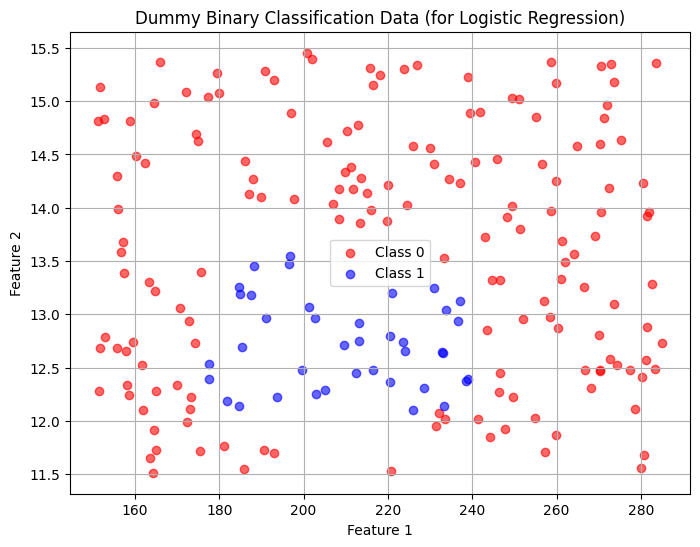

In [96]:
plt.figure(figsize=(8, 6))
plt.scatter(X[y_pred.flatten() == 0][:, 0], X[y_pred.flatten() == 0][:, 1], color="red", label="Class 0", alpha=0.6)
plt.scatter(X[y_pred.flatten() == 1][:, 0], X[y_pred.flatten() == 1][:, 1], color="blue", label="Class 1", alpha=0.6)
plt.title("Dummy Binary Classification Data (for Logistic Regression)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()